# Demo for Bi-fidelity Stochastic Subspace Descent

We use an example function 
$$f(x; r) = \lambda ((x_1^2 + x_r^2 + \sum_{i=1}^{r-1}(x_i - x_{i+1})^2)/2 - x_1)/4.$$

We set $\lambda =1$, HF function $f(x;10)$ and LF function $f(x;5)$.

In [1]:
from wrapper import *
import numpy as np
import matplotlib.pyplot as plt

In [54]:
def f_lr(x, lbd, r):
    if r > len(x):
        raise ValueError('r must be less than or equal to the length of x')
    sums = (x[0]**2 + sum((x[i] - x[i+1])**2 for i in range(0, r-1)) + x[r-1]**2)/2 - x[0]# + 1e-3 * sum(x[i]**2 for i in range(r, len(x)))
    return lbd * sums/4 + lbd * r/(8*(r+1))

lmda = 20.0
d, r1, r2 = 1000, 10, 5
f    = lambda x : f_lr(x, lmda, r1)
f_LF = lambda x : f_lr(x, lmda, r2)
x0  = np.zeros(d)

obj = objectiveFcn(f,label='Low-rank Function')
obj_lowFi= objectiveFcn(f_LF)
obj_alt = objectiveFcn(f)
learning_rate = 1/lmda
ell = 10
num_iterations = 40
learning_rate_ssd = learning_rate#/10

In [55]:
from tqdm import tqdm
num_trials = 1
gd, cd, ssdd, spsa_ls, rgfm, ssdd_ls, ssdh_ls, ssdd_bt, ssdd_hbt = [], [], [], [], [], [], [], [], []
for i in tqdm(range(num_trials)):
    # Gradient Descent
    _ = grad_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations)
    gd.append(obj.returnHistory())
    # Coordinate Descent
    _ = coor_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations/2)
    cd.append(obj.returnHistory())
    # SSD
    _ = ssd(x0,obj,ell=ell,learning_rate=learning_rate_ssd,num_iterations=num_iterations*d/ell)
    ssdd.append(obj.returnHistory())
    # SPSA
    _ = spsa(x0,obj,num_iterations=num_iterations*d)
    spsa_ls.append(obj.returnHistory())
    # Random Gredien-free Minimization
    _ = ssd(x0,obj,ell=1,learning_rate=learning_rate_ssd,num_iterations=num_iterations*d)
    rgfm.append(obj.returnHistory())
    # SSD with linesearch (LF)
    _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_lowFi,
                num_iterations=num_iterations*d/ell, linesearchIter=10 )
    ssdd_ls.append(obj.returnHistory())
    # SSD with linesearch (HF)
    _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_alt,
                num_iterations=num_iterations*d/ell, linesearchIter=10 )
    ssdh_ls.append(obj.returnHistory())
    # SSD with backtracking linesearch (BF)
    _ = ssd_bt(x0,obj,ell=ell,obj_lowFi= obj_lowFi, c=0.9,
                num_iterations=num_iterations*d/ell, linesearchIter=10 )
    ssdd_bt.append(obj.returnHistory())
    # SSD with backtracking linesearch (HF)
    _ = ssd_hbt(x0,obj,ell=ell,obj_lowFi= obj_lowFi, c=0.9,
                num_iterations=num_iterations*d/ell, linesearchIter=10 )
    ssdd_hbt.append(obj.returnHistory())
gd, cd, ssdd, ssdd_ls, ssdh_ls, spsa_ls, rgfm, ssdd_bt, ssdd_hbt = np.asarray(gd), np.asarray(cd), np.asarray(ssdd), np.asarray(ssdd_ls), np.asarray(ssdh_ls), np.asarray(spsa_ls), np.asarray(rgfm), np.asarray(ssdd_bt), np.asarray(ssdd_hbt)

  0%|          | 0/1 [00:00<?, ?it/s]

======== gradient descent ======
======== coordinate descent ========
======== SSD ===================
======== SPSA ===================
======== SSD ===================
======== SSD w/ low-fi linesearch =
======== SSD w/ low-fi linesearch =
======== SSD w/ backtracking bi-fi linesearch =
======== SSD w/ backtracking linesearch =


100%|██████████| 1/1 [01:05<00:00, 65.24s/it]


In [56]:
# # Uncomment to load results
# file = np.load('demo_res.npz')
# gd, cd, ssdd, ssdd_ls, ssdd_ls_cal = file['gd'], file['cd'], file['ssd'], file['ssd_ls'], file['ssd_ls_cal']

In [57]:
T = num_iterations * d

gd_mean, gd_std = np.mean(gd[:,10:T], axis=0), np.std(gd[:,10:T], axis=0)
cd_mean, cd_std = np.mean(cd[:,10:T], axis=0), np.std(cd[:,10:T], axis=0)
ssd_mean, ssd_std = np.mean(ssdd[:,10:T], axis=0), np.std(ssdd[:,10:T], axis=0)
spsa_mean, spsa_std = np.mean(spsa_ls[:,10:T], axis=0), np.std(spsa_ls[:,10:T], axis=0)
rgfm_mean, rgfm_std = np.mean(rgfm[:,10:T], axis=0), np.std(rgfm[:,10:T], axis=0)
ssd_ls_mean, ssd_ls_std = np.mean(ssdd_ls[:,10:T], axis=0), np.std(ssdd_ls[:,10:T], axis=0)
ssd_hls_mean, ssd_hls_std = np.mean(ssdh_ls[:,10:T], axis=0), np.std(ssdh_ls[:,10:T], axis=0)
ssd_bt_mean, ssd_bt_std = np.mean(ssdd_bt[:,10:T], axis=0), np.std(ssdd_bt[:,10:T], axis=0)
ssd_hbt_mean, ssd_hbt_std = np.mean(ssdd_hbt[:,10:T], axis=0), np.std(ssdd_hbt[:,10:T], axis=0)
# ssd_ls_cal_mean, ssd_ls_cal_std = np.mean(ssdd_ls_cal[:,10:400], axis=0), np.std(ssdd_ls_cal[:,10:400], axis=0)

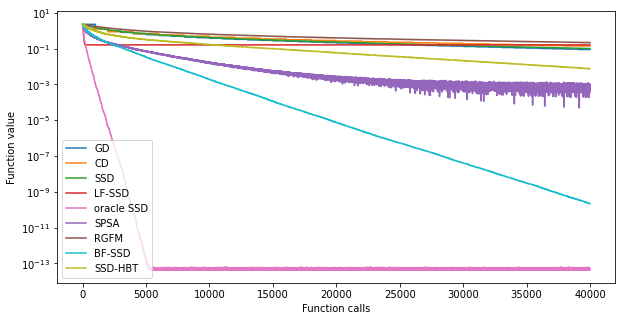

In [58]:
plt.figure(figsize=(10,5))
plt.plot(gd_mean, label='GD', color='tab:blue')
plt.fill_between(range(len(gd_mean)), gd_mean-1.94*gd_std, gd_mean+1.94*gd_std, alpha=0.2, color='tab:blue')
plt.plot(cd_mean, label='CD', color='tab:orange')
plt.fill_between(range(len(cd_mean)), cd_mean-1.94*cd_std, cd_mean+1.94*cd_std, alpha=0.2, color='tab:orange')
plt.plot(ssd_mean, label='SSD', color='tab:green')
plt.fill_between(range(len(ssd_mean)), ssd_mean-1.94*ssd_std, ssd_mean+1.94*ssd_std, alpha=0.2, color='tab:green')
plt.plot(ssd_ls_mean, label='LF-SSD', color='tab:red')
# plt.fill_between(range(len(ssd_ls_mean)), ssd_ls_mean-1.94*ssd_ls_std, ssd_ls_mean+1.94*ssd_ls_std, alpha=0.2, color='tab:red')
plt.plot(ssd_hls_mean, label='oracle SSD', color='tab:pink')
# plt.fill_between(range(len(ssd_hls_mean)), ssd_hls_mean-1.94*ssd_hls_std, ssd_hls_mean+1.94*ssd_hls_std, alpha=0.2, color='tab:pink')
plt.plot(spsa_mean, label='SPSA', color='tab:purple')
plt.fill_between(range(len(spsa_mean)), spsa_mean-1.94*spsa_std, spsa_mean+1.94*spsa_std, alpha=0.2, color='tab:purple')
plt.plot(rgfm_mean, label='RGFM', color='tab:brown')
plt.fill_between(range(len(rgfm_mean)), rgfm_mean-1.94*rgfm_std, rgfm_mean+1.94*rgfm_std, alpha=0.2, color='tab:brown')
plt.plot(ssd_bt_mean, label='BF-SSD', color='tab:cyan')
plt.fill_between(range(len(ssd_bt_mean)), ssd_bt_mean-1.94*ssd_bt_std, ssd_bt_mean+1.94*ssd_bt_std, alpha=0.2, color='tab:cyan')
plt.plot(ssd_hbt_mean, label='SSD-HBT', color='tab:olive')
plt.fill_between(range(len(ssd_hbt_mean)), ssd_hbt_mean-1.94*ssd_hbt_std, ssd_hbt_mean+1.94*ssd_hbt_std, alpha=0.2, color='tab:olive')
plt.yscale('log')
plt.xlabel('Function calls'), plt.ylabel('Function value'), plt.legend()
# plt.savefig('BF-SSD-d1000-ell3-lmda20.png', dpi=300, bbox_inches='tight')
plt.show()